In [1]:
import copy
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytagi import Normalizer
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelOptimizer,
    SKF,
    SKFOptimizer,
    ProphetDetrender,
    plot_data,
    plot_prediction,
    plot_skf_states,
    plot_states,
)
from canari.component import LocalTrend, LocalAcceleration, LstmNetwork, WhiteNoise


Importing plotly failed. Interactive plots will not work.


In [2]:
# data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LGA/LGABAR/EXT/LGA010ESAPRG988.DAT"
data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LTU/LTUBAR/PEN/ST/LTU014PIAEVA920.DAT"
df_raw = pd.read_csv(data_file,
                     sep=";",  # Semicolon as delimiter
                     quotechar='"',
                     engine="python",
                     na_values=[""],  # Treat empty strings as NaN
                     skipinitialspace=True,
                     encoding="ISO-8859-1",
                     )

In [3]:
df_raw.head()

,No pendule,Amenagement,Ouvrage,Date,Nombre Date,Niveau Reservoir (m),Deplacements cumulatif X (mm),Deplacements cumulatif Y (mm),Deplacements cumulatif Z (mm),Remarque,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,LTU014PIAEVA920,LTU,LTUBAR,2002-12-06 00:00,37596.0,151.74,-3.02,-0.70,2.35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LTU014PIAEVA920,LTU,LTUBAR,2002-12-07 00:00,37597.0,151.78,-3.02,-0.58,2.33,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LTU014PIAEVA920,LTU,LTUBAR,2002-12-08 00:00,37598.0,151.57,-2.98,-0.63,2.30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LTU014PIAEVA920,LTU,LTUBAR,2002-12-09 00:00,37599.0,151.28,-3.04,-0.50,2.26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LTU014PIAEVA920,LTU,LTUBAR,2002-12-10 00:00,37600.0,151.36,-3.05,-0.41,2.21,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# df = df_raw[["Ext/Contraction (mm)"]]
df = df_raw[["Deplacements cumulatif Z (mm)"]]

df.columns = ["ext"]
df.index = pd.to_datetime(df_raw["Date"])
# Resampling to weekly
df = df.resample("W").last()

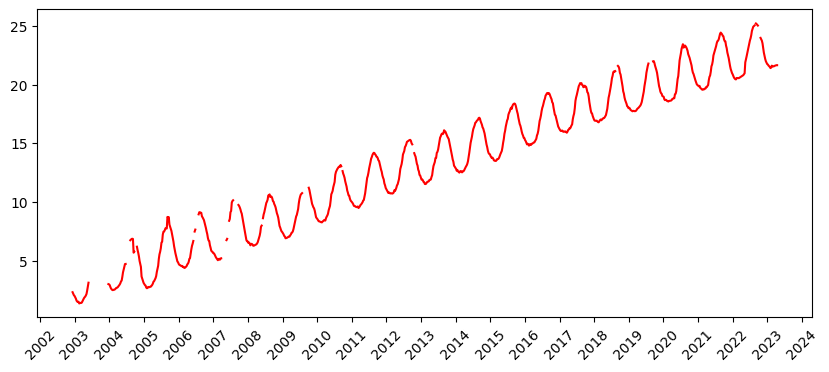

In [5]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df.index, df["ext"], color="red")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()

In [6]:
series = df["ext"]

detr = ProphetDetrender(
    freq="W",         # or "W" or "D"
    yearly_seasonality="auto",
    # weekly_seasonality="auto",
    # daily_seasonality=False,
    )  
result = detr.fit_transform(series)

trend = result["trend"]
seasonal = result["seasonal"]
residual = result["residual"]  # has NaNs exactly where series had NaNs

15:47:38 - cmdstanpy - INFO - Chain [1] start processing
15:47:38 - cmdstanpy - INFO - Chain [1] done processing


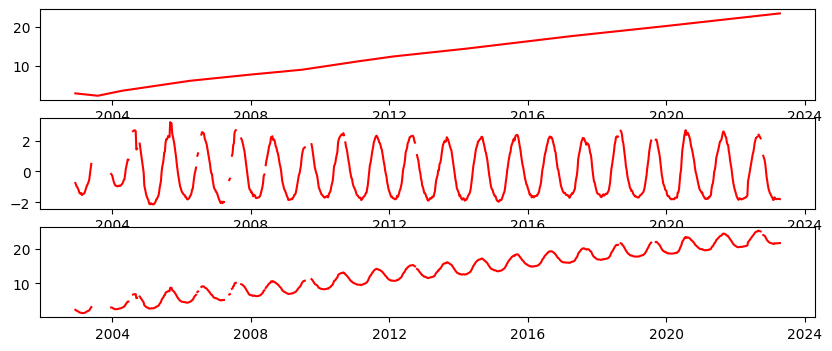

In [7]:
fig, ax = plt.subplots(3, 1,figsize=(10, 4))
ax[0].plot(trend, color="red")
ax[1].plot(seasonal + residual, color="red")
ax[2].plot(trend + seasonal + residual, color="red")

In [8]:
df_detrend = df.copy()
df_detrend["ext"] = (seasonal + residual).to_numpy()

In [9]:
# Data pre-processing
output_col = [0]
data_processor_detrend = DataProcess(
    data=df_detrend,
    time_covariates=["week_of_year"],
    train_split=0.9,
    validation_split=0.1,
    # test_split=0.1,
    output_col=output_col,
)
train_data, validation_data, _, _ = data_processor_detrend.get_splits()

data_processor = DataProcess(
    data=df,
    time_covariates=["week_of_year"],
    train_split=0.9,
    validation_split=0.1,
    output_col=output_col,
    scale_const_mean=data_processor_detrend.scale_const_mean,
    scale_const_std=data_processor_detrend.scale_const_std
)
_, _, _, all_data = data_processor.get_splits()

seed = np.random.randint(0, 100)

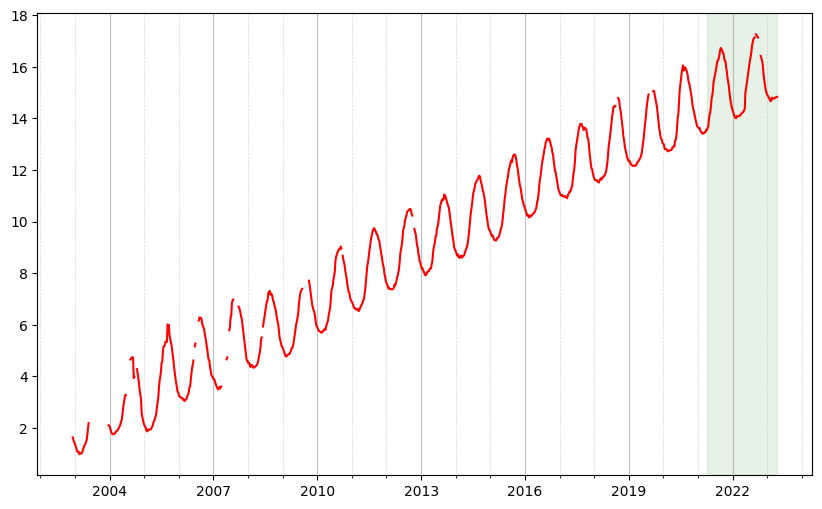

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data(
    data_processor=data_processor,
    plot_column=output_col,
    standardization=True,
    plot_test_data=False,
    sub_plot=ax,
    validation_label="y",
)

In [11]:
param_optimization = True
smoother = True
num_trial_optim_model = 100

In [12]:
######### Define model with parameters #########
def model_with_parameters(param, train_data, validation_data):
    model = Model(
        LocalTrend(),
        LstmNetwork(
            look_back_len=param["look_back_len"],
            num_features=2,
            num_layer=1,
            infer_len=52 * 3,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=smoother,
        ),
        WhiteNoise(std_error=param["sigma_v"]),
    )

    model.auto_initialize_baseline_states(train_data["y"])
    num_epoch = 50
    for epoch in range(num_epoch):
        mu_validation_preds, std_validation_preds, _ = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        mu_validation_preds_unnorm = normalizer.unstandardize(
            mu_validation_preds,
            data_processor_detrend.scale_const_mean[data_processor.output_col],
            data_processor_detrend.scale_const_std[data_processor.output_col],
        )

        std_validation_preds_unnorm = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor_detrend.scale_const_std[data_processor.output_col],
        )

        validation_obs = data_processor_detrend.get_data("validation").flatten()
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds_unnorm,
            observation=validation_obs,
            std=std_validation_preds_unnorm,
        )

        model.early_stopping(
            evaluate_metric=-validation_log_lik,
            current_epoch=epoch,
            max_epoch=num_epoch,
        )
        model.metric_optim = model.early_stop_metric

        if model.stop_training:
            break

    #### Define SKF model with parameters #########

    abnorm_model = Model(
        LocalAcceleration(),
        LstmNetwork(),
        WhiteNoise(),
    )
    skf = SKF(
        norm_model=model,
        abnorm_model=abnorm_model,
        std_transition_error=param["std_transition_error"],
        norm_to_abnorm_prob=param["norm_to_abnorm_prob"],
    )
    skf.auto_initialize_baseline_states(all_data["y"][0 : 52 * 3])
    skf.save_initial_states()

    filter_marginal_abnorm_prob, states, mu_preds, std_preds = skf.filter(
        data=all_data
    )

    mu_preds_unnorm = normalizer.unstandardize(
        mu_preds,
        data_processor.scale_const_mean[data_processor.output_col],
        data_processor.scale_const_std[data_processor.output_col],
    )

    std_preds_unnorm = normalizer.unstandardize_std(
        std_preds,
        data_processor.scale_const_std[data_processor.output_col],
    )

    obs_all = data_processor.get_data("all").flatten()
    log_lik_all = metric.log_likelihood(
        prediction=mu_preds_unnorm,
        observation=obs_all,
        std=std_preds_unnorm,
    )
    skf.metric_optim = -log_lik_all

    skf.load_initial_states()

    return skf, filter_marginal_abnorm_prob, states

(pid=98818) Importing plotly failed. Interactive plots will not work.


#   1/100 - Metric: 1.210 - Parameter: {'look_back_len': 25, 'sigma_v': 0.0682757132679779, 'std_transition_error': 1.3843536342246011e-06, 'norm_to_abnorm_prob': 7.961479657758256e-05}


(pid=98826) Importing plotly failed. Interactive plots will not work. [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


#   2/100 - Metric: 0.381 - Parameter: {'look_back_len': 28, 'sigma_v': 0.10248640536706527, 'std_transition_error': 8.92454179933845e-05, 'norm_to_abnorm_prob': 2.094237683940448e-06}
#   3/100 - Metric: 0.228 - Parameter: {'look_back_len': 12, 'sigma_v': 0.10993642286502739, 'std_transition_error': 3.1113966825061944e-05, 'norm_to_abnorm_prob': 9.325111507263543e-06}


(pid=98832) Importing plotly failed. Interactive plots will not work. [repeated 2x across cluster]


...

#  96/100 - Metric: 0.321 - Parameter: {'look_back_len': 13, 'sigma_v': 0.12323561568562269, 'std_transition_error': 4.115426944816705e-05, 'norm_to_abnorm_prob': 4.420134676733685e-06}


(pid=99336) Importing plotly failed. Interactive plots will not work.


#  97/100 - Metric: 0.188 - Parameter: {'look_back_len': 12, 'sigma_v': 0.1218423805404353, 'std_transition_error': 5.59448224683254e-05, 'norm_to_abnorm_prob': 1.1083675952669725e-05}
#  98/100 - Metric: 0.171 - Parameter: {'look_back_len': 12, 'sigma_v': 0.12439522072493932, 'std_transition_error': 6.816696963339334e-05, 'norm_to_abnorm_prob': 4.334668382249775e-06}


2025-11-20 15:54:57,643	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/Model_optimizer' in 0.0315s.
2025-11-20 15:54:57,644	ERROR tune.py:1037 -- Trials did not complete: [objective_49f63e36]


#  99/100 - Metric: 16.072 - Parameter: {'look_back_len': 13, 'sigma_v': 0.10713754667623171, 'std_transition_error': 6.008987781226105e-05, 'norm_to_abnorm_prob': 3.393199163843457e-06}
-----
Optimal parameters at trial #73: {'look_back_len': 12, 'sigma_v': 0.17045098188859378, 'std_transition_error': 3.990901145919084e-05, 'norm_to_abnorm_prob': 1.0349159826930803e-05}
-----


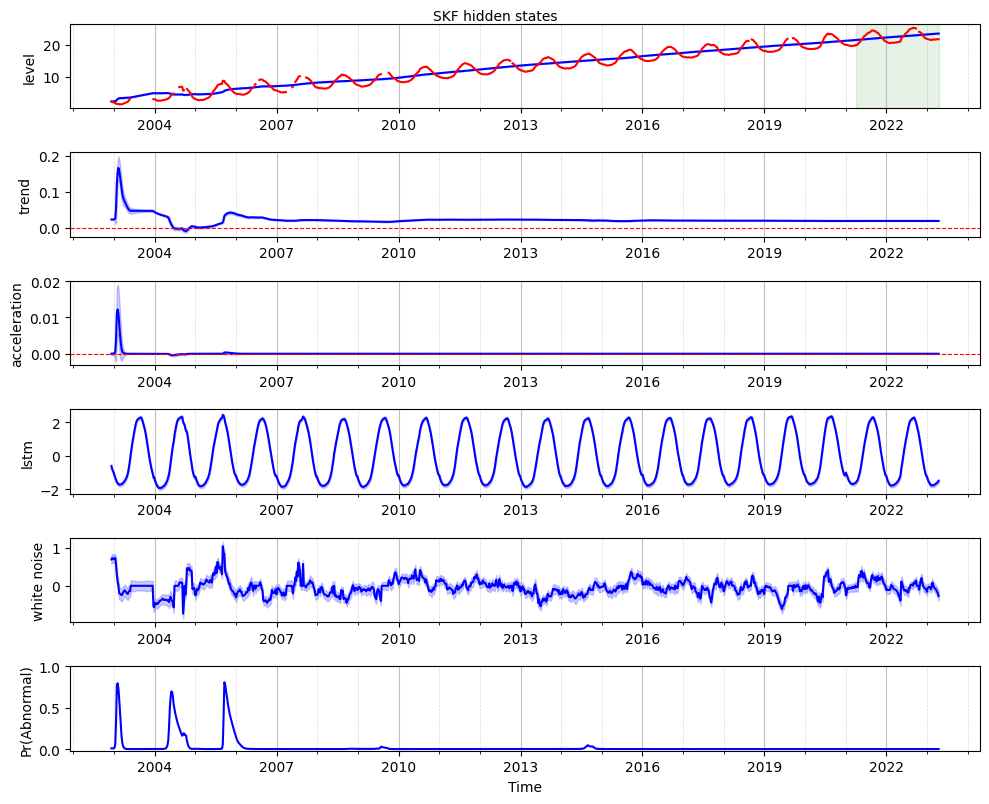

In [13]:
if param_optimization:
    param_space = {
        "look_back_len": [12, 52],
        "sigma_v": [1e-3, 2e-1],
        "std_transition_error": [1e-6, 1e-4],
        "norm_to_abnorm_prob": [1e-6, 1e-4],
    }
    # Define optimizer
    model_optimizer = ModelOptimizer(
        model=model_with_parameters,
        param_space=param_space,
        train_data=train_data,
        validation_data=validation_data,
        num_optimization_trial=num_trial_optim_model,
        # num_startup_trials=20,
    )
    model_optimizer.optimize()
    # Get best model
    param = model_optimizer.get_best_param()
    skf_optim, filter_marginal_abnorm_prob, states = model_with_parameters(
        param, train_data, validation_data
    )

    skf_optim_dict = skf_optim.get_dict()
    skf_optim_dict["model_param"] = param
    skf_optim_dict["cov_names"] = train_data["cov_names"]
    with open("/Users/vuongdai/GitHub/canari/saved_params/LTU014z.pkl", "wb") as f:
        pickle.dump(skf_optim_dict, f)
else:
    with open("/Users/vuongdai/GitHub/canari/saved_params/LTU014z.pkl", "rb") as f:
        skf_optim_dict = pickle.load(f)
    skf_optim = SKF.load_dict(skf_optim_dict)

filter_marginal_abnorm_prob, states, *_ = skf_optim.filter(data=all_data)
smooth_marginal_abnorm_prob, states = skf_optim.smoother()

fig, ax = plot_skf_states(
    data_processor=data_processor,
    states=states,
    model_prob=filter_marginal_abnorm_prob,
)
fig.suptitle("SKF hidden states", fontsize=10, y=1)
plt.savefig("/Users/vuongdai/GitHub/canari/saved_results/LTU014z_1.png")
plt.show()